In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import typing as t

In [ ]:
import statsmodels as sm

# 1. Загрузка временного ряда

In [ ]:
train = pd.read_csv('/content/train_min_temps.csv')
train

,Date,linear
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
2734,1988-06-27,10.0
2735,1988-06-28,6.7
2736,1988-06-29,9.4
2737,1988-06-30,9.3


In [ ]:
test = pd.read_csv('/content/test_min_temps.csv')
test

,Date,linear
0,1988-07-02,5.8
1,1988-07-03,4.9
2,1988-07-04,5.0
3,1988-07-05,8.4
4,1988-07-06,12.3
...,...,...
908,1990-12-27,14.0
909,1990-12-28,13.6
910,1990-12-29,13.5
911,1990-12-30,15.7


# 2. Изучение структуры временного ряда

STL (Seasonal-Trend Decomposition using LOESS) - это метод разложения временного ряда на три компоненты:
- тренд;
- сезонность;
- остаток.

Метод основан на локальной регрессии LOESS. Он предполагает аддитивную структуру временного ряда:

$$
y_t = T_t + S_t + R_t,
$$

где:
- $T_t$ - тренд (trend);
- $S_t$ - сезонность (seasonality);
- $R_t$ - остаток (residual).

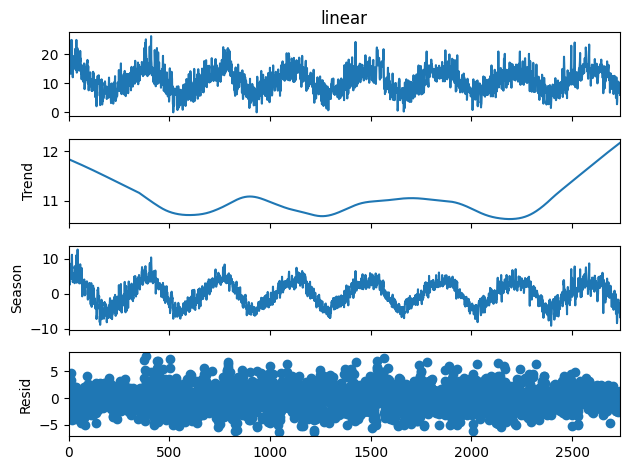

In [ ]:
from statsmodels.tsa.seasonal import STL


stl = STL(train['linear'], period=365)
result = stl.fit()
result.plot();

# 3. Определение параметров модели ARIMA (SARIMA)

$\text{ARIMA}$ и $\text{SARIMA}$ - это мощные статистические модели для прогнозирования временных рядов на основе прошлых данных.



$\text{ARIMA}(p, d, q)$ - это статистическая модель для анализа и прогнозирования временных рядов, которая описывает текущее значение ряда через комбинацию его прошлых значений $\text{AR}(p)$, прошлых случайных ошибок $\text{MA}(q)$ и операции дифференцирования ($d$).

Дифференцирование используется для устранения тренда и приведения ряда к стационарному виду следующим образом:

$$
y_t = \gamma_t - \gamma_{t - d}
$$

После чего модель оценивает зависимость между текущими и прошлыми наблюдениями:

$$
y_t' = \alpha + \underbrace{\varphi_1y_{t-1} + \varphi_2y_{t-2} + \cdots + \varphi_p y_{t-p}}_{\text{AR}(p)} + \underbrace{\varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}}_{\text{MA}(q)},
$$

где:
- $\alpha$ - обучаемый параметр смещения;
---
- $\varphi_i$ - обучаемый коэффициент авторегрессии $\text{AR}(p)$, $i = \overline{1,p}$;
- $y_{t-i}$ - текущее наблюдение временного ряда (вплоть до момента времени $t-p$);
---
- $\theta_j$ - обучаемый коэффициент скользящего среднего $\text{MA}(q)$, $j = \overline{1,q}$;
- $\varepsilon_{t-j}$ - текущая ошибка из декомпозиции временного ряда (вплоть до момента времени $t-q$).

$\text{SARIMA}(p, d, q)\times(P, D, Q, s)$ - это расширение модели ARIMA, предназначенное для временных рядов с сезонной структурой. Она дополнительно учитывает повторяющиеся закономерности, возникающие через фиксированные интервалы времени (например, годовую, квартальную или суточную сезонность), включая зависимости между значениями ряда на расстоянии одного или нескольких сезонных периодов.

Для этого применяется не только обычное дифференцирование $d$, но и сезонное $D$:

$$
y_t = \gamma_t = \gamma_{t - s \times D},
$$

где $s$ - период сезонности.

А потом берется прогноз $y_t'$ ARIMA, к которому добавляется:

- $P$ авторегрессионных сезонных компонент:
$$
+\varphi_s^1 y_{t - s} +\varphi_{s}^2 y_{t - 2 \times s} + ... +\varphi_{s}^P y_{t - P \times s}
$$

- $Q$ компонент сезонного скользящего среднего:
$$
+\theta_S^1 \varepsilon_{t-s} + \theta_{s}^2 \varepsilon_{t-2 \times s} + \cdots + \theta_{s}^Q \varepsilon_{t-Q \times s}
$$

Основной проблемой этих моделей является требование, которое предъявляется к исходным данным - они должны быть **стационарными**!

1. Если зафиксированы параметры $d$, $D$, $q$, $Q$, $p$, $P$, то есть зафиксирована структура модели $\text{ARIMA}$, то параметры $\alpha$, $\varphi$, $\theta$ можно подобрать с помощью метода наименьших квадратов. Фактически происходит настраивание привычной регрессии методом минимизации квадратичной ошибки.
2. Параметры $d, D$, которые задают порядки дифференцирования, необходимо подбирать так, чтобы ряд стал стационарным. Рекомендуется начинать с сезонного дифференцирования, потому что уже после него ряд может оказаться стационарным. Дело в том, что выгодно дифференцировать ряд как можно меньше раз, потому что с увеличением количества дифференцирований растёт дисперсия итогового прогноза.

https://education.yandex.ru/handbook/ml/article/modeli-vida-arima

## 3.1. Как бороться с нестационарностью временного ряда?

Временной ряд называется **стационарным**, если его страуктура не зависит от предыдущих значений и момента времени (если его среднее значение, дисперсия и структура не меняются со временем).

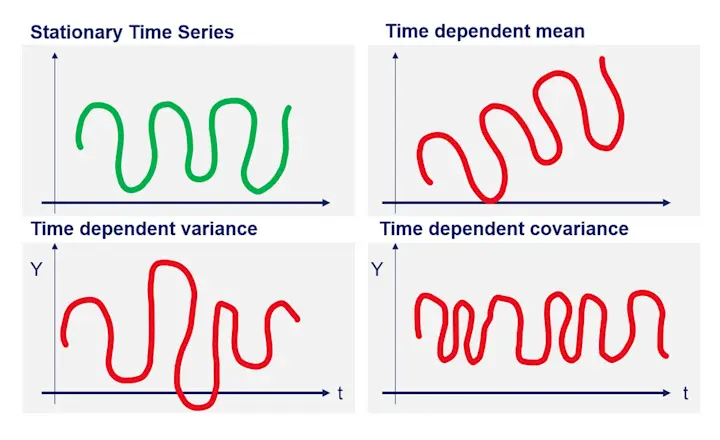

Для нестационарного ряда часто оказывается, что получаемый после дифференцирования ряд является стационарным. Такая операция позволяет стабилизировать среднее значение ряда и избавиться от тренда, а иногда даже от сезонности.

Сезонное и обычное дифференцирование могут применяться к ряду в любом порядке (но лучше начинать с сезонного, так как ряд сразу может оказаться стационарным).

Наиболее популярными методами определения стационарности ВР являются следующие два:
- статистический тест Дикки-Фуллера (ADF);
- визуальное изучение графика временного ряда и разбивка его на трендовые, сезонные и остаточные компоненты (из определения следует, что ряды, в которых присутствует тренд, являются нестационарными, кроме того, нестационарны ряды с сезонностью).

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
adfuller(train['linear'])[1]

np.float64(0.0011822810683369707)

In [ ]:
s = 365
train['linear'].diff(s)

,linear
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2734,3.2
2735,-0.8
2736,1.4
2737,1.0


In [ ]:
train['s_diff'] = train['linear'].diff(s)
train['s_diff']

,s_diff
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2734,3.2
2735,-0.8
2736,1.4
2737,1.0


In [ ]:
adfuller(train['s_diff'][s:])[1]

0.0

In [ ]:
d = 0
D = 1

<Axes: >

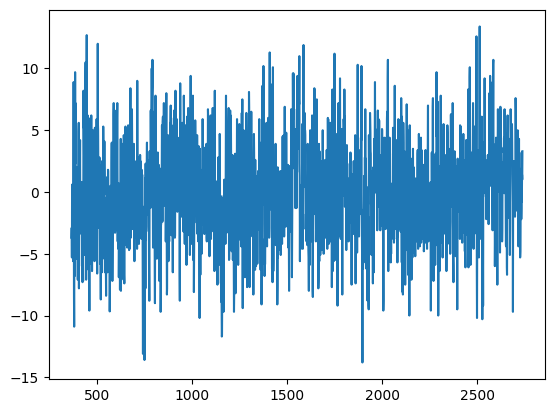

In [ ]:
train['s_diff'][s:].plot()

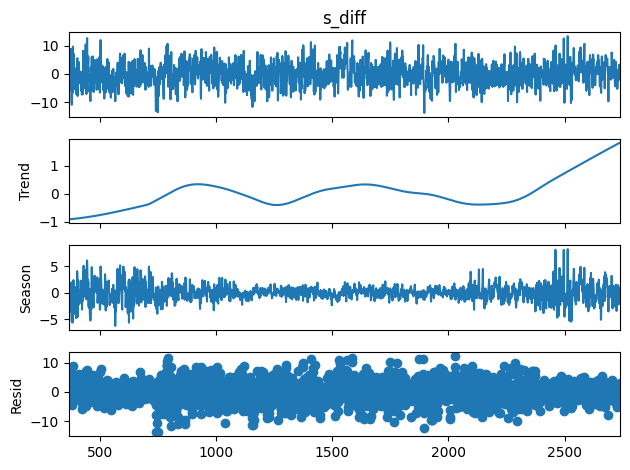

In [ ]:
stl = STL(train['s_diff'][s:], period=s)
result = stl.fit()
result.plot();

## 3.2. Исследование автокорреляции исходных данных

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

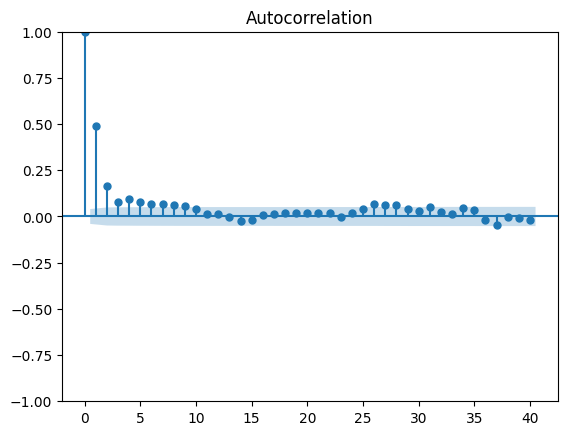

In [ ]:
plot_acf(train['s_diff'][s:], lags=40);

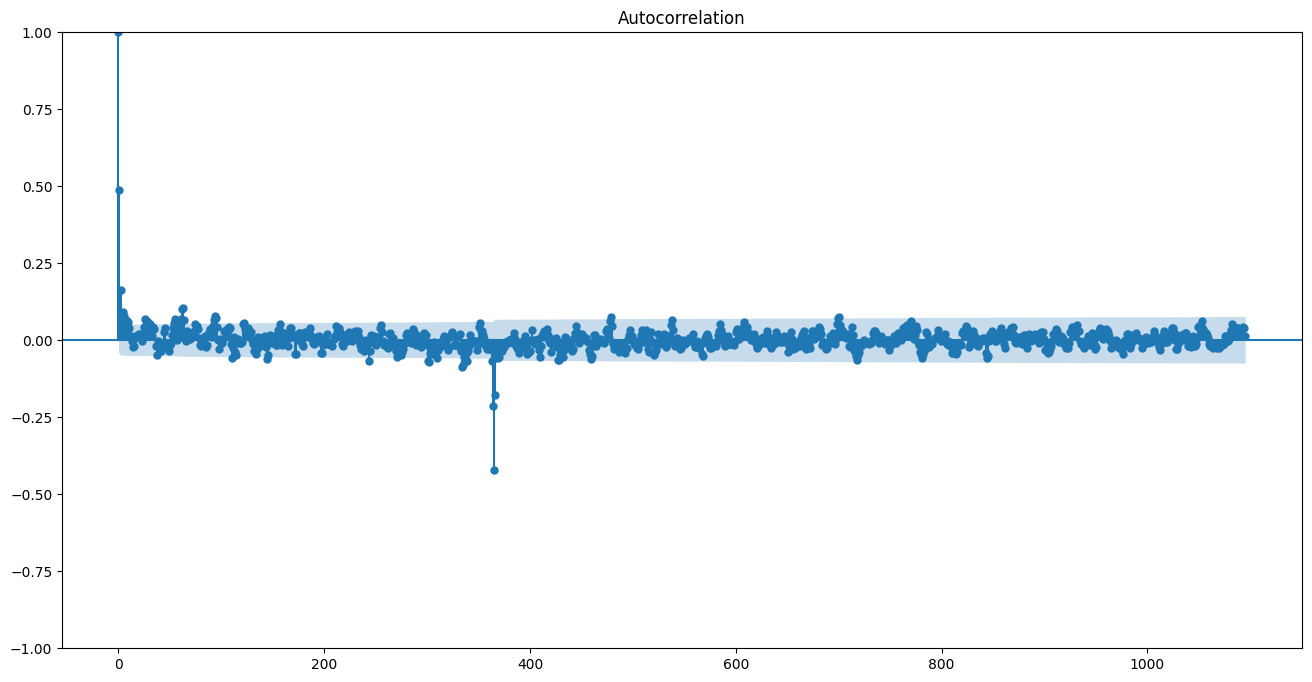

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_acf(train['s_diff'][s:], lags=3*s, ax=ax);

In [ ]:
q = 3
Q = 1

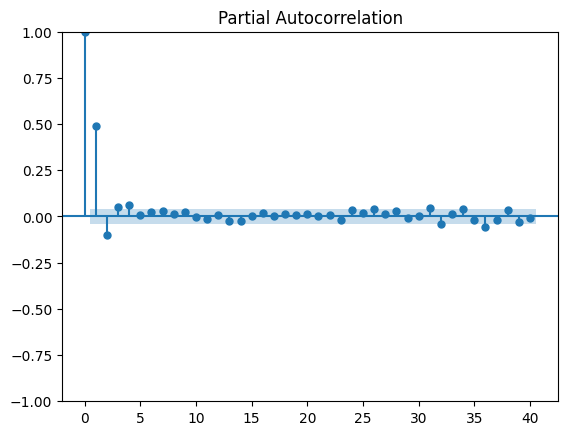

In [ ]:
plot_pacf(train['s_diff'][s:], lags=40);

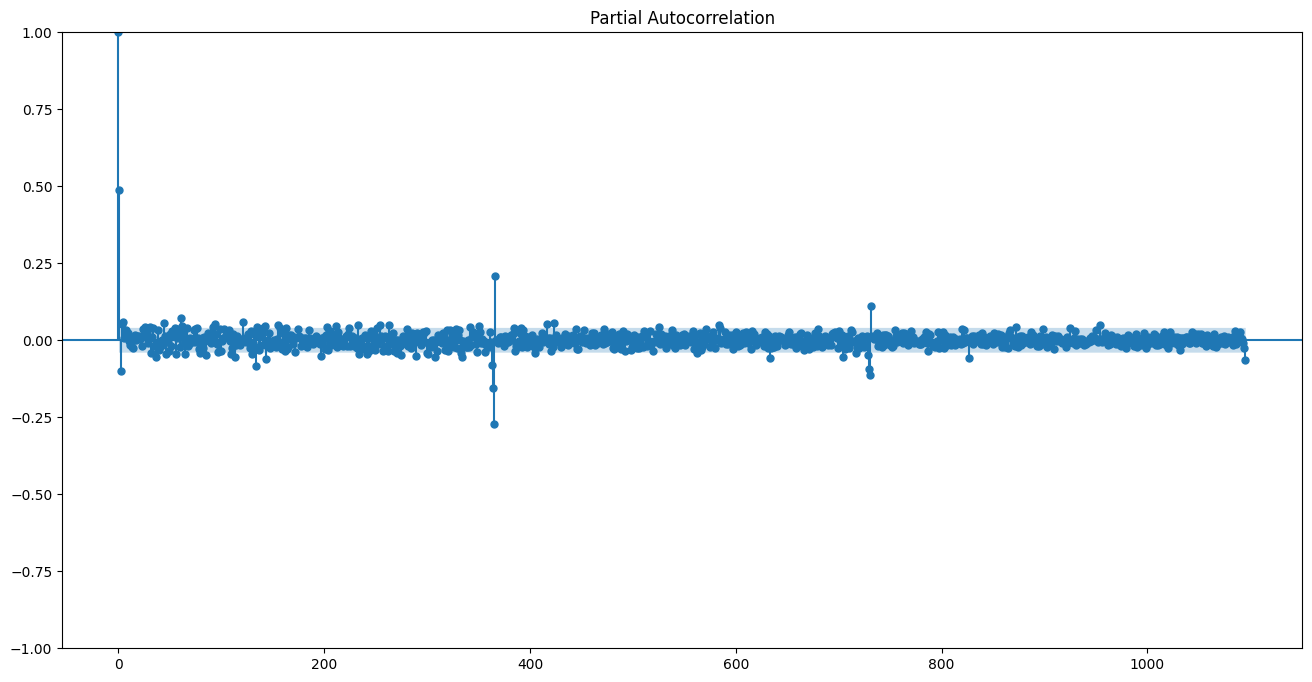

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_pacf(train['s_diff'][s:], lags=3*s, ax=ax);

In [ ]:
# fig, ax = plt.subplots(figsize=(16, 8))
# plot_pacf(train['s_diff'][s:], lags=4*s, ax=ax);

In [ ]:
p = 4
P = 2

# 4. Обучение модели SARIMA. Подбор гиперпараметров

In [ ]:
# !pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


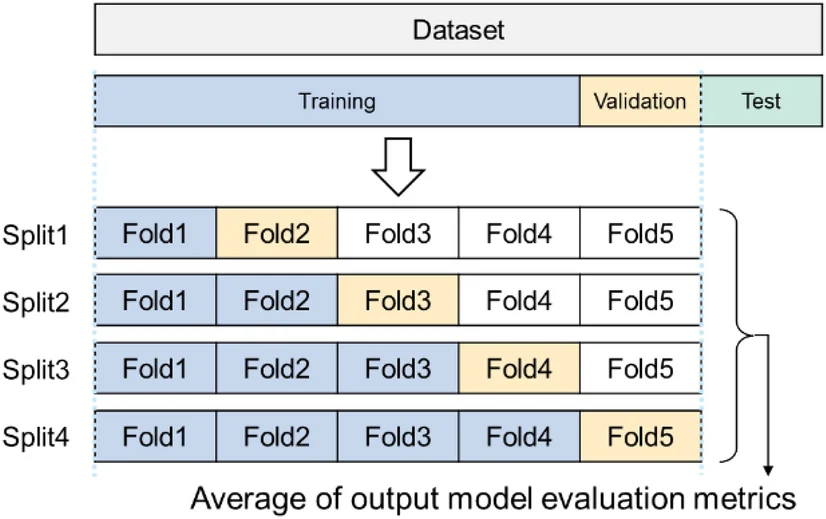

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA


auto_arima = AutoARIMA(
    seasonal=True, season_length=s,
    max_p=p, max_q=q,
    max_P=P, max_Q=Q,
    d=d, D=D,
    stepwise=True,
    trace=True
)

sf = StatsForecast(
    models=[auto_arima],
    freq='D',
    n_jobs=2
)

In [ ]:
train

,Date,linear,s_diff
0,1981-01-01,20.7,NaN
1,1981-01-02,17.9,NaN
2,1981-01-03,18.8,NaN
3,1981-01-04,14.6,NaN
4,1981-01-05,15.8,NaN
...,...,...,...
2734,1988-06-27,10.0,3.2
2735,1988-06-28,6.7,-0.8
2736,1988-06-29,9.4,1.4
2737,1988-06-30,9.3,1.0


In [ ]:
df = pd.DataFrame({
    'unique_id': 'series_1',
    'ds': train['Date'],
    'y': train['linear']
})[-1000:]

In [ ]:
cv_results = sf.cross_validation(
    df=df,
    h=30,
    n_windows=8,
    step_size=30
)


ARIMA(2,0,2)(0,1,0)[365] with drift        :3147.220742866606

ARIMA(0,0,0)(0,1,0)[365] with drift        :3304.2155362886706

ARIMA(1,0,0)(0,1,0)[365] with drift        :3156.1844484813937

ARIMA(0,0,1)(0,1,0)[365] with drift        :3163.0228995907064

ARIMA(0,0,0)(0,1,0)[365]                   :3305.14584791989

ARIMA(1,0,2)(0,1,0)[365] with drift        :3147.035098443785

ARIMA(0,0,2)(0,1,0)[365] with drift        :3145.389973234446

ARIMA(0,0,3)(0,1,0)[365] with drift        :3146.8378522843773

ARIMA(1,0,1)(0,1,0)[365] with drift        :3149.328865521666

ARIMA(1,0,3)(0,1,0)[365] with drift        :3149.024859649251

ARIMA(0,0,2)(0,1,0)[365]                   :3144.7154059628197

ARIMA(0,0,1)(0,1,0)[365]                   :3162.8331471133497

ARIMA(1,0,2)(0,1,0)[365]                   :3146.4753723935046

ARIMA(0,0,3)(0,1,0)[365]                   :3146.2345722408313

ARIMA(1,0,1)(0,1,0)[365]                   :3148.5910102436924

ARIMA(1,0,3)(0,1,0)[365]                   :31

In [ ]:
cv_results

,unique_id,ds,cutoff,y,AutoARIMA
0,series_1,1988-05-26,1988-05-25,12.6,4.674248
1,series_1,1988-05-27,1988-05-25,10.9,4.090730
2,series_1,1988-05-28,1988-05-25,8.7,6.400000
3,series_1,1988-05-29,1988-05-25,9.3,10.800000
4,series_1,1988-05-30,1988-05-25,6.3,7.800000
...,...,...,...,...,...
235,series_1,1988-06-27,1988-06-01,10.0,6.800000
236,series_1,1988-06-28,1988-06-01,6.7,7.500000
237,series_1,1988-06-29,1988-06-01,9.4,8.000000
238,series_1,1988-06-30,1988-06-01,9.3,8.300000


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


errors_by_cutoff = cv_results.groupby('cutoff').apply(lambda df: pd.Series({
    'mae': mean_absolute_error(df['y'], df['AutoARIMA']),
    'mape': mean_absolute_percentage_error(df['y'], df['AutoARIMA']),
})).reset_index()

errors_by_cutoff

/tmp/ipykernel_15834/2608101141.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  errors_by_cutoff = cv_results.groupby('cutoff').apply(lambda df: pd.Series({


,cutoff,mae,mape
0,1988-05-25,2.307834,0.261477
1,1988-05-26,1.925369,0.232738
2,1988-05-27,1.890323,0.230988
3,1988-05-28,1.965862,0.238004
4,1988-05-29,1.895909,0.229825
5,1988-05-30,1.920431,0.231366
6,1988-05-31,1.952671,0.234720
7,1988-06-01,2.036291,0.250519


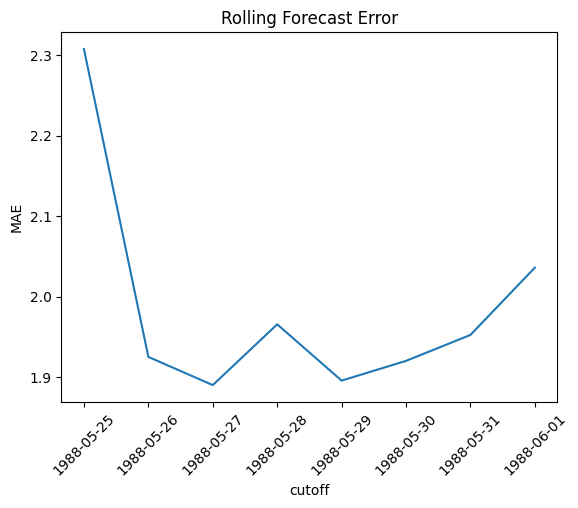

In [ ]:
plt.plot(errors_by_cutoff['cutoff'], errors_by_cutoff['mae']);
plt.xlabel('cutoff');
plt.ylabel('MAE');
plt.title('Rolling Forecast Error');
plt.xticks(rotation=45);

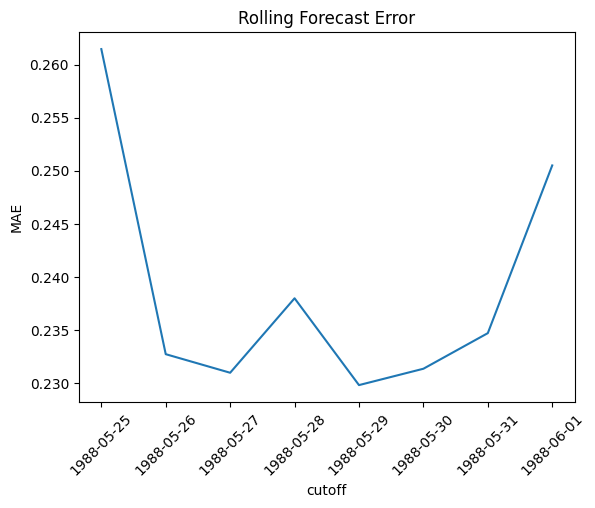

In [ ]:
plt.plot(errors_by_cutoff['cutoff'], errors_by_cutoff['mape']);
plt.xlabel('cutoff');
plt.ylabel('MAE');
plt.title('Rolling Forecast Error');
plt.xticks(rotation=45);

In [ ]:
sf.fit(df)


ARIMA(2,0,2)(0,1,0)[365] with drift        :3325.0393101307445

ARIMA(0,0,0)(0,1,0)[365] with drift        :3491.9324261223533

ARIMA(1,0,0)(0,1,0)[365] with drift        :3334.329880495669

ARIMA(0,0,1)(0,1,0)[365] with drift        :3341.9812665551494

ARIMA(0,0,0)(0,1,0)[365]                   :3493.5048546058465

ARIMA(1,0,2)(0,1,0)[365] with drift        :3324.307232370204

ARIMA(0,0,2)(0,1,0)[365] with drift        :3322.584260887854

ARIMA(0,0,3)(0,1,0)[365] with drift        :3324.0851053914603

ARIMA(1,0,1)(0,1,0)[365] with drift        :3326.9961085604896

ARIMA(1,0,3)(0,1,0)[365] with drift        :3326.225580724962

ARIMA(0,0,2)(0,1,0)[365]                   :3322.241024279819

ARIMA(0,0,1)(0,1,0)[365]                   :3342.235869344824

ARIMA(1,0,2)(0,1,0)[365]                   :3324.079070386086

ARIMA(0,0,3)(0,1,0)[365]                   :3323.822499770306

ARIMA(1,0,1)(0,1,0)[365]                   :3326.581158248429

ARIMA(1,0,3)(0,1,0)[365]                   :3325

StatsForecast(models=[AutoARIMA])

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


model = SARIMAX(
    df['y'],
    order=(0, 0, 2),
    seasonal_order=(0, 1, 0, s)
)

results = model.fit()

NameError: name 'df' is not defined